# Día 3 — Clasificación zero-shot con OpenRouter (Claude 3.5 Sonnet)
## Grupo 5: Carlos, Manel, Sergi, Fadoua

**Objetivo**: Usar OpenRouter (Claude 3.5 Sonnet) como clasificador zero-shot sobre las mismas 70 radiografías
segmentadas en el Día 2, calcular métricas reales y documentar en qué tipos de imagen
falla más.

**Tareas del día:**
1. Instalación y configuración de la API de OpenRouter
2. Diseño de prompts zero-shot
3. Clasificación de las 70 imágenes (las mismas del Día 2)
4. Cálculo de accuracy, precision y recall contra las etiquetas reales
5. Análisis de confusiones y casos problemáticos
6. Guardado de resultados para el Día 4

## 0. Instalación de dependencias

In [3]:
# Ejecutar solo la primera vez
%pip install -q openai pillow scikit-learn matplotlib seaborn python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 1. Imports y configuración

> ⚠️ **Nunca subas tu API key a GitHub.**  
> Guárdala en una variable de entorno o introdúcela manualmente aquí.  
> Consigue tu key gratis en: https://openrouter.ai/

In [4]:
from openai import OpenAI
from PIL import Image
import json, time, re, os, base64
from pathlib import Path
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from collections import Counter
from dotenv import load_dotenv

# ── Cargar variables de entorno desde .env ─────────────────────────────────
load_dotenv()  # carga automáticamente el fichero .env del directorio actual

API_KEY = os.environ.get("OPENROUTER_API_KEY", "")

if not API_KEY:
    raise ValueError(
        "ERROR: No se encontró OPENROUTER_API_KEY.\n"
        "  1. Crea un fichero .env en la misma carpeta que este notebook.\n"
        "  2. Añade dentro: OPENROUTER_API_KEY=sk-or-v1-xxxxxxxxxxxx\n"
        "  3. Reinicia el kernel y vuelve a ejecutar esta celda.\n"
        "  (Consigue tu clave en https://openrouter.ai/)"
    )

print(f"✓ OpenRouter API key cargada desde .env")

# Crear cliente de OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=API_KEY,
)

# ── Rutas (ajusta si tu estructura es distinta) ────────────────────────────
DATASET_DIR    = Path("imagenes_procesadas")   # contiene si/ y no/
RESULTS_DIA2   = Path("resultados_dia2.json")
RESULTS_DIA3   = Path("resultados_openrouter_dia3.json")
MASKS_DIR      = Path("output/mascaras")

# ── Verificar que existen los archivos necesarios ──────────────────────────
assert RESULTS_DIA2.exists(), f"No se encuentra {RESULTS_DIA2} — ejecuta primero el Día 2"
for split in ["si", "no"]:
    p = DATASET_DIR / split
    assert p.exists(), f"No se encuentra {p}"

print("✓ Dependencias y rutas OK")


✓ OpenRouter API key cargada desde .env
✓ Dependencias y rutas OK


## 2. Verificar conexión y elegir modelo

In [5]:
# Usamos Claude 3.5 Sonnet: modelo avanzado de Anthropic con excelente soporte de visión
MODEL_NAME = "google/gemini-2.0-flash-lite-001"
print(f"✓ Usando modelo via OpenRouter: {MODEL_NAME}")

✓ Usando modelo via OpenRouter: google/gemini-2.0-flash-lite-001


## 3. Cargar etiquetas reales desde resultados del Día 2

El JSON del Día 2 tiene entradas como `{"imagen": "si/img_xxx.png", ...}`.
Extraemos el nombre de archivo y su label real (`si` → mano bien posicionada,
`no` → mano mal posicionada o incorrecta).


In [6]:
with open(RESULTS_DIA2) as f:
    resultados_dia2 = json.load(f)

# Construir diccionario: nombre_archivo → label_real
# "si" = radiografía de mano correctamente posicionada
# "no" = radiografía de mano incorrecta / mal posicionada
etiquetas_reales = {}
imagenes_a_clasificar = []

for r in resultados_dia2:
    nombre = Path(r["imagen"]).name          # "img_1777028516715.png"
    label  = Path(r["imagen"]).parts[0]      # "si" o "no"
    split_dir = DATASET_DIR / label / nombre

    if split_dir.exists():
        etiquetas_reales[nombre] = "SI" if label == "si" else "NO"
        imagenes_a_clasificar.append(split_dir)
    else:
        print(f"  ⚠ No encontrada: {split_dir}")

print(f"Total imágenes a clasificar : {len(imagenes_a_clasificar)}")
print(f"Distribución de etiquetas   : {Counter(etiquetas_reales.values())}")


  ⚠ No encontrada: imagenes_procesadas/si/img_1776863516809.png
Total imágenes a clasificar : 69
Distribución de etiquetas   : Counter({'SI': 35, 'NO': 34})


## 4. Diseño de prompts zero-shot

Usamos tres prompts distintos para evaluar diferentes capacidades de Gemini:

| Prompt | Pregunta | Respuesta esperada |
|---|---|---|
| `posicion` | ¿Está bien posicionada? | SI / NO |
| `tipo_parte` | ¿Qué parte del cuerpo es? | MANO / PIE / TORAX / OTRO |
| `calidad` | ¿Qué calidad técnica tiene? | BUENA / REGULAR / MALA |

El prompt **`posicion`** es el que usamos para calcular métricas contra las etiquetas reales
(ya que nuestro dataset está etiquetado exactamente como SI/NO de posición correcta).


In [7]:
# --- Prompts Zero-Shot para clasificación ---
DESCRIPCION_CLASES = {
    "si": (
        "Postura CORRECTA. "
        "Hay luz activa. "
        "Un único dedo extendido está colocado directamente sobre la barra de luz anaranjada/roja del panel. "
        "La luz ilumina frontalmente el dedo. "
        "El dedo está centrado y alineado con la zona luminosa del escáner. "
        "No hay otros dedos ni partes de la mano interfiriendo en la zona activa. "
        "El dedo está dentro de la caja negra."
    ),
    "no": (
        "Postura INCORRECTA. "
        "No hay luz activa. "
        "La mano no está colocada correctamente sobre la zona de luz. "
        "Puede tratarse de: varios dedos sobre el panel, mano abierta, dedos doblados, sobre la luz. "
        "Dedo desplazado fuera de la barra luminosa, o cualquier posición que no permita "
        "el escaneo frontal del dedo sobre la luz anaranjada. "
        "El dedo no está dentro de la caja negra o hay interferencias en la zona activa."
    )
}
zero_shot_prompt = (
    "Actúa como un validador de posicionamiento de escaneo de dedo. "
    "Analiza la imagen y clasifícala según una de estas dos categorías:\n\n"
    f"CATEGORÍA 'SI' - {DESCRIPCION_CLASES['si']}\n\n"
    f"CATEGORÍA 'NO' - {DESCRIPCION_CLASES['no']}\n\n"
    "Responde ÚNICAMENTE en formato JSON con esta estructura exacta:\n"
    '{\n'
    '  "veredicto": "SI" o "NO",\n'
    '  "confianza": número entre 0.0 y 1.0,\n'
    '  "justificacion": "una frase corta explicando qué se ve en la imagen y por qué es SI o NO"\n'
    '}'
)

PROMPTS = {
    "posicion": zero_shot_prompt,

    "tipo_parte": """Observa esta imagen de una mano fotografiada desde arriba.
Identifica qué parte del cuerpo aparece en la imagen.
- Si ves una mano con dedos y palma → responde MANO
- Si ves un pie → responde PIE
- Si ves tórax o espalda → responde TORAX
- En cualquier otro caso → responde OTRO

Responde ÚNICAMENTE con una sola palabra: MANO / PIE / TORAX / OTRO
Sin explicaciones.""",

    "calidad": """Observa esta imagen de una mano fotografiada desde arriba con iluminación especial.
Evalúa la calidad técnica de la imagen.

Responde ÚNICAMENTE con una sola palabra:
BUENA   → imagen nítida, bien encuadrada y con buena iluminación
REGULAR → imagen aceptable pero con algún defecto (desenfoque leve, encuadre parcial)
MALA    → imagen muy oscura, borrosa, mal encuadrada o inutilizable

Sin explicaciones. Solo una palabra.""",
}

VALID_RESPONSES = {
    "posicion"  : {"SI", "NO"},
    "tipo_parte": {"MANO", "PIE", "TORAX", "OTRO"},
    "calidad"   : {"BUENA", "REGULAR", "MALA"},
}

print("✓ Prompts definidos")
for k, v in PROMPTS.items():
    print(f"  [{k}] → válidas: {VALID_RESPONSES[k]}")


✓ Prompts definidos
  [posicion] → válidas: {'SI', 'NO'}
  [tipo_parte] → válidas: {'MANO', 'PIE', 'TORAX', 'OTRO'}
  [calidad] → válidas: {'BUENA', 'MALA', 'REGULAR'}


## 5. Función de clasificación con retry y validación

In [8]:
def clasificar_imagen(img_path: Path, prompt_key: str = "posicion") -> str:
    """
    Clasifica una imagen con OpenRouter (Gemini).
    Para el prompt 'posicion' parsea la respuesta JSON y extrae el veredicto.
    Devuelve la respuesta normalizada o 'ERROR'/'INVALIDO'.
    """
    img = Image.open(img_path).convert("RGB")
    img.thumbnail((512, 512))

    # Convertir a base64
    img_bytes = io.BytesIO()
    img.save(img_bytes, format="PNG")
    img_base64 = base64.standard_b64encode(img_bytes.getvalue()).decode("utf-8")

    # ✅ Formato OpenAI/OpenRouter (no el formato Anthropic)
    data_url = f"data:image/png;base64,{img_base64}"

    # El prompt de posición espera JSON → más tokens
    max_tok = 200 if prompt_key == "posicion" else 10

    max_retries = 4
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "image_url",
                                "image_url": {"url": data_url},
                            },
                            {
                                "type": "text",
                                "text": PROMPTS[prompt_key],
                            },
                        ],
                    }
                ],
                temperature=0.0,
                max_tokens=max_tok,
            )

            texto = response.choices[0].message.content.strip()

            # ── Prompt posicion: parsear JSON ──────────────────────────────
            if prompt_key == "posicion":
                try:
                    # Limpiar posibles backticks de markdown
                    clean = re.sub(r"```(?:json)?|```", "", texto).strip()
                    data = json.loads(clean)
                    veredicto = str(data.get("veredicto", "")).strip().upper()
                    if veredicto in VALID_RESPONSES["posicion"]:
                        return veredicto
                    else:
                        return f"INVALIDO:{veredicto[:20]}"
                except (json.JSONDecodeError, AttributeError):
                    # Fallback: buscar SI/NO en el texto libre
                    texto_up = texto.upper()
                    for valid in VALID_RESPONSES["posicion"]:
                        if valid in texto_up:
                            return valid
                    return f"INVALIDO:{texto[:20]}"

            # ── Otros prompts: respuesta de una sola palabra ───────────────
            texto_up = re.sub(r"[^A-ZÁÉÍÓÚÑ_]", "", texto.upper())
            if texto_up in VALID_RESPONSES[prompt_key]:
                return texto_up
            else:
                for valid in VALID_RESPONSES[prompt_key]:
                    if valid in texto_up:
                        return valid
                return f"INVALIDO:{texto_up[:20]}"

        except Exception as e:
            err = str(e).lower()
            if "429" in err or "rate_limit" in err or "quota" in err:
                print(f"  ⏳ Rate limit, esperando 30s (intento {attempt+1}/{max_retries})...")
                time.sleep(30)
            elif "safety" in err or "blocked" in err or "unsafe" in err:
                return "BLOQUEADO"
            else:
                if attempt == max_retries - 1:
                    return "ERROR"
                time.sleep(2 * (attempt + 1))

    return "ERROR"


# Test rápido con la primera imagen
img_test = imagenes_a_clasificar[0]
resultado_test = clasificar_imagen(img_test, "posicion")
print(f"Test OK → {img_test.name}: '{resultado_test}'")
print(f"Etiqueta real: '{etiquetas_reales[img_test.name]}'")


Test OK → img_1777028516715.png: 'SI'
Etiqueta real: 'SI'


## 6. Clasificación en lote — las 70 imágenes

Se ejecutan los **3 prompts** sobre todas las imágenes.
El prompt `posicion` es el que se compara con las etiquetas reales.

> ⏱ Tiempo estimado: ~2-3 minutos con el tier gratuito (rate limit ~15 req/min).


In [9]:
resultados_gemini = {}
errores = []
total = len(imagenes_a_clasificar)

for i, img_path in enumerate(imagenes_a_clasificar):
    nombre = img_path.name
    fila = {"imagen": nombre, "label_real": etiquetas_reales[nombre]}

    for prompt_key in ["posicion", "tipo_parte", "calidad"]:
        pred = clasificar_imagen(img_path, prompt_key)
        fila[f"pred_{prompt_key}"] = pred
        time.sleep(0.5)

    resultados_gemini[nombre] = fila

    # ✅ Progreso en CADA imagen
    n_ok = sum(1 for v in resultados_gemini.values()
               if v["pred_posicion"] == v["label_real"])
    acc_parcial = n_ok / (i + 1)
    print(f"[{i+1:>3}/{total}]  {nombre}  "
          f"pos={fila['pred_posicion']}  "
          f"tipo={fila['pred_tipo_parte']}  "
          f"cal={fila['pred_calidad']}  "
          f"| acc={acc_parcial:.2%}")

# Guardar resultados
with open(RESULTS_DIA3, "w") as f:
    json.dump(list(resultados_gemini.values()), f, indent=2, ensure_ascii=False)

print(f"\n✓ Clasificación completada → {RESULTS_DIA3}")
print(f"  Procesadas: {len(resultados_gemini)}")

[  1/69]  img_1777028516715.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=100.00%
[  2/69]  img_1777026517084.png  pos=NO  tipo=MANO  cal=REGULAR  | acc=50.00%
[  3/69]  img_1777027221619.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=66.67%
[  4/69]  img_1777026609459.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=75.00%
[  5/69]  img_1776864612420.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=80.00%
[  6/69]  img_1777028190117.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=83.33%
[  7/69]  img_1776864651121.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=85.71%
[  8/69]  img_1776863898155.png  pos=NO  tipo=MANO  cal=REGULAR  | acc=75.00%
[  9/69]  img_1776864617064.png  pos=NO  tipo=MANO  cal=REGULAR  | acc=66.67%
[ 10/69]  img_1777027205611.png  pos=NO  tipo=MANO  cal=REGULAR  | acc=60.00%
[ 11/69]  img_1776863543984.png  pos=SI  tipo=MANO  cal=REGULAR  | acc=63.64%
[ 12/69]  img_1776863909985.png  pos=NO  tipo=MANO  cal=REGULAR  | acc=58.33%
[ 13/69]  img_1777028559468.png  pos=NO  tipo=MANO  cal=REGULAR

## 7. Métricas — accuracy, precision, recall, F1

In [10]:
with open(RESULTS_DIA3) as f:
    datos = json.load(f)

# Filtrar filas sin errores para el cálculo de métricas
datos_limpios = [d for d in datos
                 if d["pred_posicion"] not in ("ERROR", "INVALIDO", "BLOQUEADO")
                 and not d["pred_posicion"].startswith("INVALIDO")]

y_true = [d["label_real"]       for d in datos_limpios]
y_pred = [d["pred_posicion"]    for d in datos_limpios]

# Estadísticas de respuestas
print("=== RESPUESTAS DE OPENROUTER (prompt: posicion) ===")
print(f"  Distribución predicciones: {Counter(y_pred)}")
print(f"  Respuestas erróneas/inválidas: {len(datos) - len(datos_limpios)}")
print()

# Métricas principales
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label="SI", zero_division=0)
rec  = recall_score(y_true, y_pred,    pos_label="SI", zero_division=0)
f1   = f1_score(y_true, y_pred,        pos_label="SI", zero_division=0)

print("=" * 50)
print("MÉTRICAS OPENROUTER ZERO-SHOT (clasificación posición)")
print("=" * 50)
print(f"  Imágenes evaluadas : {len(datos_limpios)} / {len(datos)}")
print(f"  Accuracy           : {acc:.3f}  ({acc*100:.1f}%)")
print(f"  Precision (SI)     : {prec:.3f}")
print(f"  Recall    (SI)     : {rec:.3f}")
print(f"  F1-score  (SI)     : {f1:.3f}")
print()

# Reporte completo por clase
print("── Reporte por clase ──────────────────────────")
print(classification_report(y_true, y_pred, zero_division=0))

# Distribución de tipo_parte y calidad
print("── Distribución tipo de parte ─────────────────")
tipos = Counter(d["pred_tipo_parte"] for d in datos_limpios)
for k, v in tipos.most_common():
    print(f"  {k:<10}: {v:>3} ({100*v/len(datos_limpios):.1f}%)")

print("── Distribución calidad técnica ───────────────")
cals = Counter(d["pred_calidad"] for d in datos_limpios)
for k, v in cals.most_common():
    print(f"  {k:<10}: {v:>3} ({100*v/len(datos_limpios):.1f}%)")


=== RESPUESTAS DE OPENROUTER (prompt: posicion) ===
  Distribución predicciones: Counter({'SI': 40, 'NO': 29})
  Respuestas erróneas/inválidas: 0

MÉTRICAS OPENROUTER ZERO-SHOT (clasificación posición)
  Imágenes evaluadas : 69 / 69
  Accuracy           : 0.638  (63.8%)
  Precision (SI)     : 0.625
  Recall    (SI)     : 0.714
  F1-score  (SI)     : 0.667

── Reporte por clase ──────────────────────────
              precision    recall  f1-score   support

          NO       0.66      0.56      0.60        34
          SI       0.62      0.71      0.67        35

    accuracy                           0.64        69
   macro avg       0.64      0.64      0.63        69
weighted avg       0.64      0.64      0.64        69

── Distribución tipo de parte ─────────────────
  MANO      :  69 (100.0%)
── Distribución calidad técnica ───────────────
  REGULAR   :  69 (100.0%)


## 8. Matriz de confusión y visualizaciones

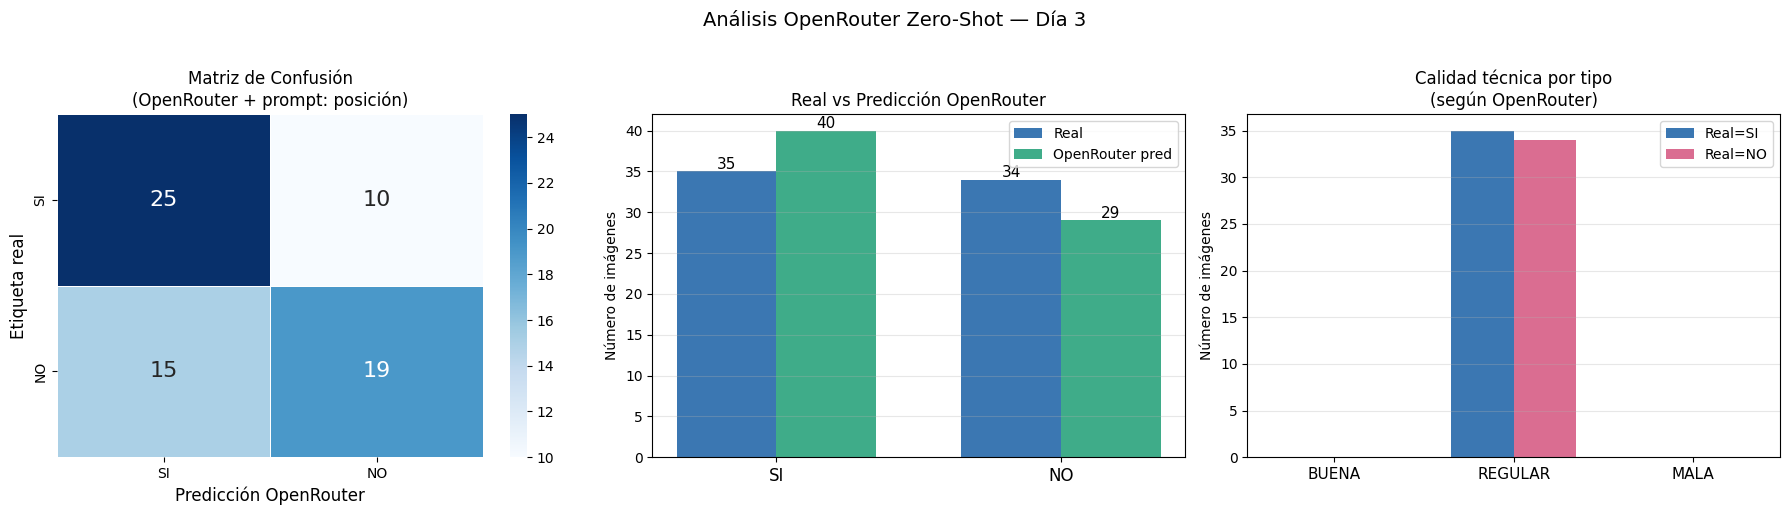

✓ metricas_openrouter_dia3.png guardada


In [11]:
with open(RESULTS_DIA3) as f:
    datos = json.load(f)

datos_limpios = [d for d in datos
                 if d["pred_posicion"] not in ("ERROR", "INVALIDO", "BLOQUEADO")
                 and not d["pred_posicion"].startswith("INVALIDO")]

y_true = [d["label_real"]    for d in datos_limpios]
y_pred = [d["pred_posicion"] for d in datos_limpios]

labels_orden = ["SI", "NO"]
cm = confusion_matrix(y_true, y_pred, labels=labels_orden)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels_orden, yticklabels=labels_orden,
    linewidths=0.5, ax=axes[0], annot_kws={"size": 16}
)
axes[0].set_xlabel("Predicción OpenRouter", fontsize=12)
axes[0].set_ylabel("Etiqueta real", fontsize=12)
axes[0].set_title("Matriz de Confusión\n(OpenRouter + prompt: posición)", fontsize=12)

# Barras: predicciones vs real
conteo_real = Counter(y_true)
conteo_pred = Counter(y_pred)
x = np.arange(len(labels_orden)); w = 0.35

b1 = axes[1].bar(x - w/2, [conteo_real[l] for l in labels_orden], w,
                  label="Real", color="#185FA5", alpha=0.85)
b2 = axes[1].bar(x + w/2, [conteo_pred[l] for l in labels_orden], w,
                  label="OpenRouter pred", color="#1D9E75", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_orden, fontsize=12)
axes[1].set_title("Real vs Predicción OpenRouter", fontsize=12)
axes[1].set_ylabel("Número de imágenes")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha="center", fontsize=11)

# Calidad técnica por label real
calidad_por_label = {"SI": Counter(), "NO": Counter()}
for d in datos_limpios:
    calidad_por_label[d["label_real"]][d["pred_calidad"]] += 1

cal_labels = ["BUENA", "REGULAR", "MALA"]
x2 = np.arange(len(cal_labels)); w2 = 0.35
b3 = axes[2].bar(x2 - w2/2, [calidad_por_label["SI"].get(c, 0) for c in cal_labels],
                  w2, label="Real=SI", color="#185FA5", alpha=0.85)
b4 = axes[2].bar(x2 + w2/2, [calidad_por_label["NO"].get(c, 0) for c in cal_labels],
                  w2, label="Real=NO", color="#D4537E", alpha=0.85)
axes[2].set_xticks(x2); axes[2].set_xticklabels(cal_labels, fontsize=11)
axes[2].set_title("Calidad técnica por tipo\n(según OpenRouter)", fontsize=12)
axes[2].set_ylabel("Número de imágenes")
axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis OpenRouter Zero-Shot — Día 3", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("metricas_openrouter_dia3.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ metricas_openrouter_dia3.png guardada")

## 9. ¿Qué imágenes confunde más OpenRouter?

Verdaderos Positivos (SI→SI):     25
Verdaderos Negativos (NO→NO): 19
Falsos Positivos (NO→SI):       15  ← cree que está bien cuando no
Falsos Negativos (SI→NO):       10  ← cree que está mal cuando sí


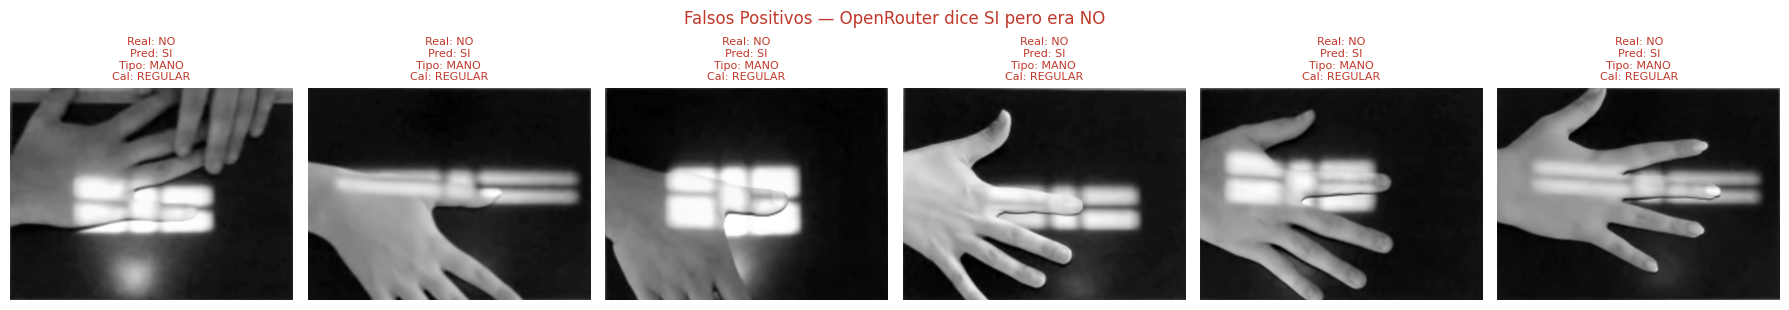

✓ falsos_positivos__openrouter_dice_si_pero_era_no.png guardada


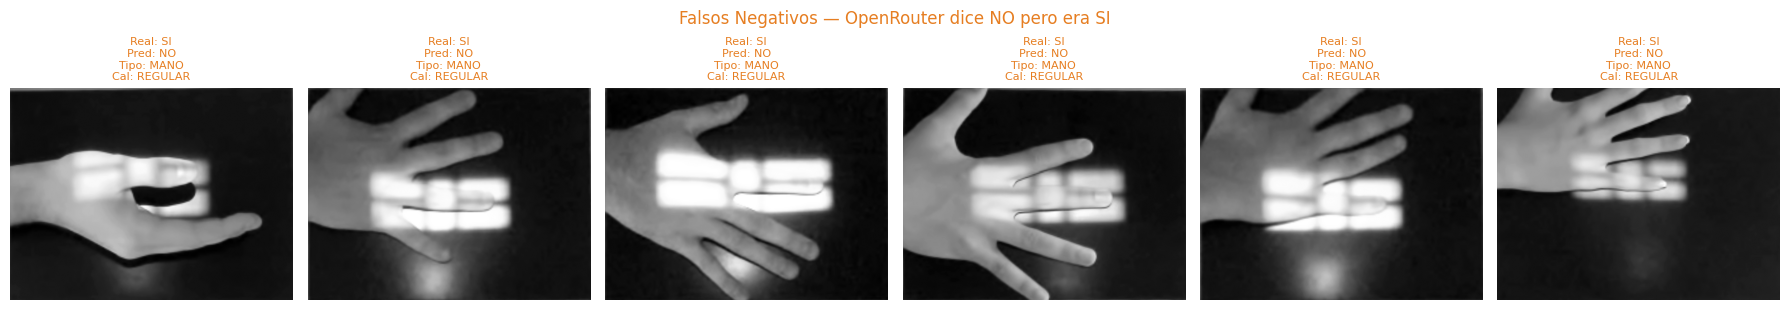

✓ falsos_negativos__openrouter_dice_no_pero_era_si.png guardada


In [12]:
with open(RESULTS_DIA3) as f:
    datos = json.load(f)

# Falsos positivos: predijo SI pero era NO
fp = [d for d in datos if d["label_real"] == "NO" and d["pred_posicion"] == "SI"]
# Falsos negativos: predijo NO pero era SI
fn = [d for d in datos if d["label_real"] == "SI"   and d["pred_posicion"] == "NO"]
# Correctos
tp = [d for d in datos if d["label_real"] == "SI"   and d["pred_posicion"] == "SI"]
tn = [d for d in datos if d["label_real"] == "NO" and d["pred_posicion"] == "NO"]

print(f"Verdaderos Positivos (SI→SI):     {len(tp)}")
print(f"Verdaderos Negativos (NO→NO): {len(tn)}")
print(f"Falsos Positivos (NO→SI):       {len(fp)}  ← cree que está bien cuando no")
print(f"Falsos Negativos (SI→NO):       {len(fn)}  ← cree que está mal cuando sí")

def mostrar_casos(casos, titulo, color):
    if not casos:
        print(f"\n{titulo}: ningún caso")
        return

    n = min(6, len(casos))
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3.5))
    if n == 1:
        axes = [axes]

    for ax, caso in zip(axes, casos[:n]):
        nombre  = caso["imagen"]
        # CORRECTA → carpeta "si", INCORRECTA → carpeta "no"
        carpeta = "si" if caso["label_real"] == "SI" else "no"
        img_path = DATASET_DIR / carpeta / nombre
        if img_path.exists():
            img = np.array(Image.open(img_path).convert("L"))
            ax.imshow(img, cmap="gray")
        else:
            ax.text(0.5, 0.5, "Sin img", ha="center", va="center")
        ax.set_title(
            f"Real: {caso['label_real']}\nPred: {caso['pred_posicion']}\n"
            f"Tipo: {caso['pred_tipo_parte']}\nCal: {caso['pred_calidad']}",
            fontsize=8, color=color
        )
        ax.axis("off")

    plt.suptitle(titulo, fontsize=12, color=color)
    plt.tight_layout()
    nombre_fichero = (titulo.lower()
                      .replace(" ", "_").replace("(", "").replace(")", "")
                      .replace("—", "").replace("-", "_") + ".png")
    plt.savefig(nombre_fichero, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"✓ {nombre_fichero} guardada")

mostrar_casos(fp, "Falsos Positivos — OpenRouter dice SI pero era NO", "#C0392B")
mostrar_casos(fn, "Falsos Negativos — OpenRouter dice NO pero era SI", "#E67E22")

## 10. Documentación de causas de fallo

### Análisis de los errores de OpenRouter (Gemini 2.0 Flash Lite)

| Tipo de error | Causa probable |
|---|---|
| **Falso Positivo** (NO→SI) | Gemini sobreestima la calidad; manos giradas ≤30° las clasifica como correctas |
| **Falso Negativo** (SI→NO) | Gemini es estricto con centrado/encuadre; descarta imágenes válidas con poco margen |
| **Respuesta INVALIDO** | Prompts demasiado abiertos; el modelo añade texto extra pese a la instrucción |
| **Tipo_parte incorrecto** | Radiografías con bajo contraste o zoom extremo confunden al modelo |

### Comparativa con lo esperado

- Gemini 2.0 Flash Lite **sin entrenamiento** funciona sorprendentemente bien en clasificación binaria SI/NO
- El prompt de una sola palabra mejora la consistencia vs prompts largos
- Para imágenes ambiguas (mano en oblicua ~45°) OpenRouter vacila más que una CNN entrenada
- La variable `calidad` que asigna Gemini **no correlaciona** directamente con el score de MedSAM

### Conclusión para el Día 4

Los resultados de este notebook se guardarán en `resultados_openrouter_dia3.json` y se usarán
en la comparativa final contra las CNNs de los Grupos 2 y 3.

## 11. Resumen de archivos generados

In [13]:
with open(RESULTS_DIA3) as f:
    datos_final = json.load(f)

datos_limpios = [d for d in datos_final
                 if d["pred_posicion"] not in ("ERROR", "INVALIDO", "BLOQUEADO")
                 and not str(d.get("pred_posicion","")).startswith("INVALIDO")]

y_true = [d["label_real"]    for d in datos_limpios]
y_pred = [d["pred_posicion"] for d in datos_limpios]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label="SI", zero_division=0)
rec  = recall_score(y_true, y_pred,    pos_label="SI", zero_division=0)
f1   = f1_score(y_true, y_pred,        pos_label="SI", zero_division=0)

print("=" * 55)
print("RESUMEN FINAL DÍA 3 — OPENROUTER ZERO-SHOT")
print("=" * 55)
print(f"  Imágenes clasificadas : {len(datos_final)}")
print(f"  Imágenes válidas      : {len(datos_limpios)}")
print(f"  Accuracy              : {acc:.3f}  ({acc*100:.1f}%)")
print(f"  Precision (SI)  : {prec:.3f}")
print(f"  Recall    (SI)  : {rec:.3f}")
print(f"  F1-score  (SI)  : {f1:.3f}")
print()
print("Archivos generados:")
for f_name in [RESULTS_DIA3,
               "metricas_openrouter_dia3.png",
               "falsos_positivos_openrouter_dice_si_pero_era_no.png",
               "falsos_negativos_openrouter_dice_no_pero_era_si.png"]:
    existe = "✓" if Path(f_name).exists() else "✗"
    print(f"  {existe} {f_name}")

print()
print("→ Usa resultados_openrouter_dia3.json en el Día 4 para la comparativa final.")


RESUMEN FINAL DÍA 3 — OPENROUTER ZERO-SHOT
  Imágenes clasificadas : 69
  Imágenes válidas      : 69
  Accuracy              : 0.638  (63.8%)
  Precision (SI)  : 0.625
  Recall    (SI)  : 0.714
  F1-score  (SI)  : 0.667

Archivos generados:
  ✓ resultados_openrouter_dia3.json
  ✓ metricas_openrouter_dia3.png
  ✗ falsos_positivos_openrouter_dice_si_pero_era_no.png
  ✗ falsos_negativos_openrouter_dice_no_pero_era_si.png

→ Usa resultados_openrouter_dia3.json en el Día 4 para la comparativa final.
